In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from IPython.display import display
from astropy.coordinates import SkyCoord
import astropy.units as u
from functools import reduce

In [35]:
# Define column names based on the header in the SRL file
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

In [36]:
spw = [
       2,
       3 , 
       4, 
       5, 
       6, 
       8, 
       15, 
       16, 
       17
       ]

In [37]:
srl_file_paths = []
dataframes = []

for s in spw:
    paths = [
        f'../paper1/23/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/25/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/32/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl',
        f'../paper1/36/spw{s}-2.5arcsec-nit5000--awproject.pybdsf.srl'
    ]
    srl_file_paths.append(paths)
    
    spw_data = []
    for path in paths:
        try:
            df = pd.read_csv(path, delim_whitespace=True, comment='#', names=column_names)
            spw_data.append(df)
        except FileNotFoundError:
            print(f"File not found: {path}")
    
    if spw_data:
        combined_df = pd.concat(spw_data, ignore_index=True)
        dataframes.append(combined_df)

# Optionally, check the content of dataframes
print(f"Total dataframes read: {len(dataframes)}")

Total dataframes read: 9


/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_71053/2154577651.py:10: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)


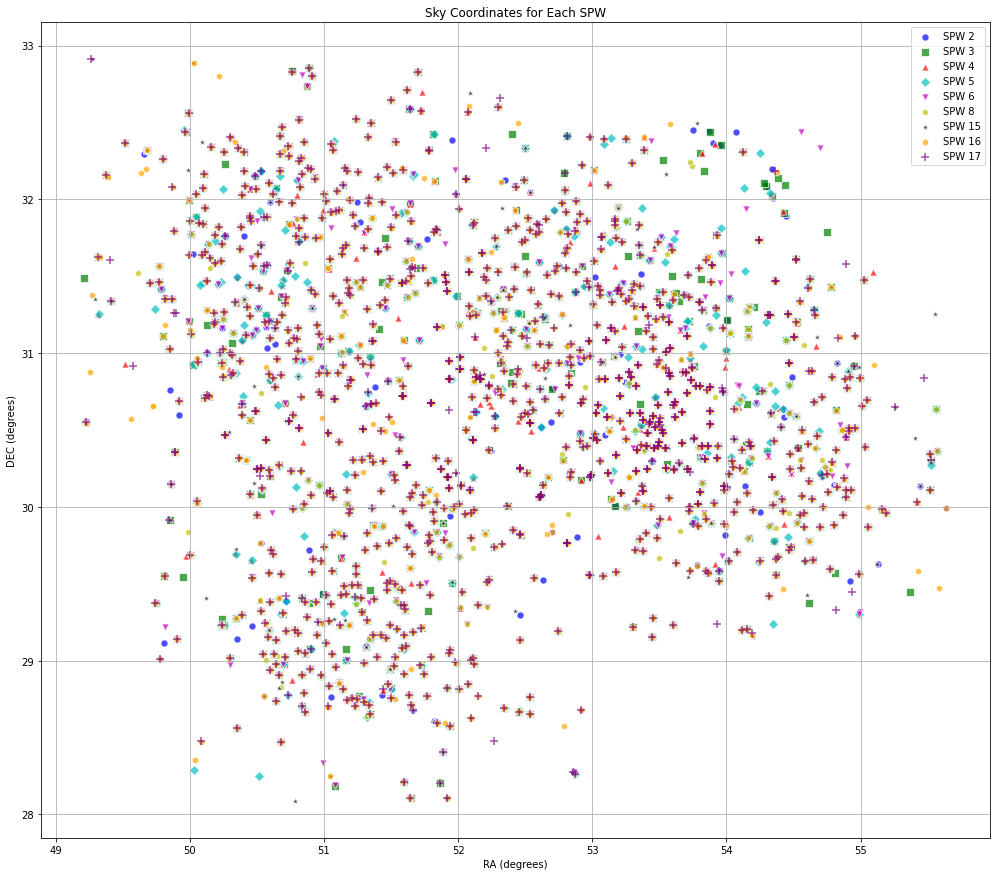

In [38]:
# Define markers and colors for different SPWs
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple']

# Plotting RA and DEC using SkyCoord
plt.figure(figsize=(17, 15))
for i, (df, marker, color) in enumerate(zip(dataframes, markers, colors)):
    # Convert RA and DEC to SkyCoord
    coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
    plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw[i]}', alpha=0.7, edgecolors='w', s=50, marker=marker, color=color)

plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('Sky Coordinates for Each SPW')
plt.legend()
plt.grid(True)
plt.show()


In [39]:
# Identify repeated sources in each SPW dataframe
repeated_sources = []

for i, df in enumerate(dataframes):
    # Round RA and DEC to two decimal places
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Group by rounded RA and DEC to find duplicates
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    repeated_sources.append(duplicated)
    
    print(f"Repeated sources in SPW {spw[i]}:")
    print(duplicated[['RA', 'DEC']])

Repeated sources in SPW 2:
             RA        DEC
2     52.294577  31.532462
4     52.177611  31.654401
6     52.131666  30.846564
7     52.108900  30.439661
8     52.080299  31.529005
...         ...        ...
1134  52.909444  30.429580
1135  52.826810  30.791657
1136  52.808577  29.767772
1137  52.607077  30.063120
1140  52.461602  30.250997

[249 rows x 2 columns]
Repeated sources in SPW 3:
             RA        DEC
2     52.360728  31.046903
4     52.177597  31.654310
6     52.107641  30.439645
7     52.117391  31.851084
8     52.080241  31.528958
...         ...        ...
1192  52.826848  30.791865
1193  52.809008  29.767377
1194  52.606475  30.063954
1196  52.533320  30.548617
1199  52.461176  30.250697

[237 rows x 2 columns]
Repeated sources in SPW 4:
             RA        DEC
3     52.165324  30.833224
4     52.177840  31.653968
5     52.108611  30.440053
6     52.080277  31.529023
8     52.056170  32.132268
...         ...        ...
1226  52.826773  30.791755
1227  5

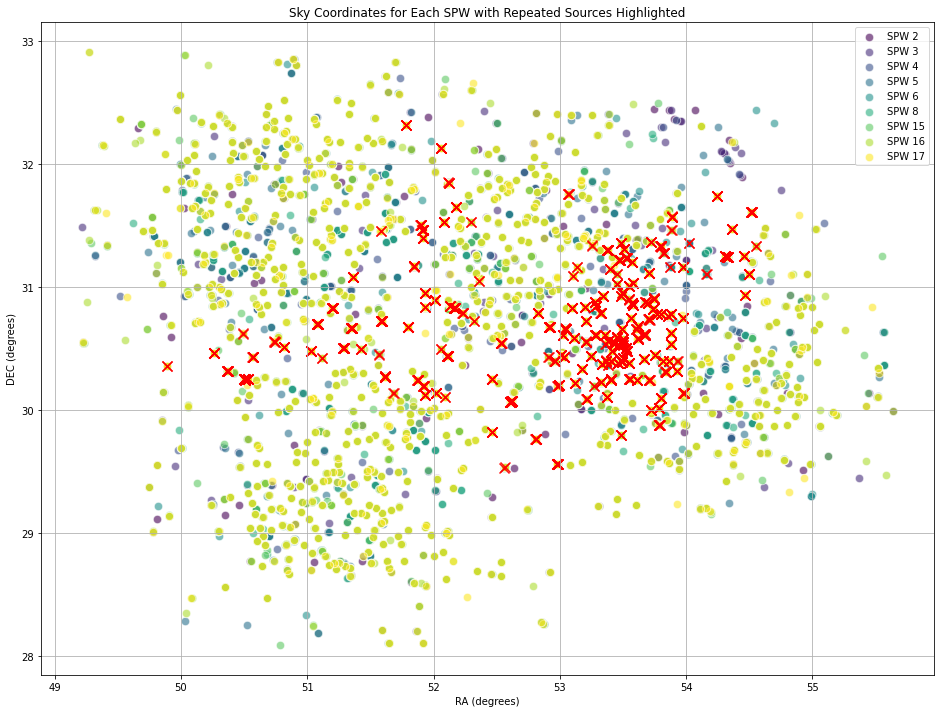

In [40]:
# Define a colormap
cmap = plt.get_cmap('viridis', len(spw))

# Create a figure for plotting
plt.figure(figsize=(16, 12))

# Initialize a list to store repeated sources
repeated_sources = []

# Plot original data points
for i, (df, spw_value) in enumerate(zip(dataframes, spw)):
    # Round RA and DEC to two decimal places
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Group by rounded RA and DEC to find duplicates
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    repeated_sources.append((spw_value, duplicated))
    
    # Convert RA and DEC to SkyCoord
    coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
    plt.scatter(coords.ra.deg, coords.dec.deg, label=f'SPW {spw_value}', alpha=0.6, edgecolors='w', s=70, color=cmap(i), marker='o')

# Plot repeated sources
for spw_value, df in repeated_sources:
    if not df.empty:
        coords = SkyCoord(ra=df['RA'].values * u.degree, dec=df['DEC'].values * u.degree, frame='icrs')
        plt.scatter(coords.ra.deg, coords.dec.deg, alpha=0.9, s=100, color='red', marker='x')

# Final plot adjustments
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')
plt.title('Sky Coordinates for Each SPW with Repeated Sources Highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
for i, df in enumerate(dataframes):
    # Round RA and DEC to two decimal places for identifying duplicates
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    
    # Print the shape before replacement
    print(f"Shape of DataFrame for SPW {spw[i]} before replacement: {df.shape}")
    
    duplicated = df[df.duplicated(subset=['RA_rounded', 'DEC_rounded'], keep=False)]
    if not duplicated.empty:
        # Print the duplicates before replacement
        print(f"Repeated sources in SPW {spw[i]} before replacement:")
        print(duplicated[['RA', 'DEC', 'E_Total_flux']])
        
        # Keep the source with the smallest 'E_Total_flux'
        df = df.loc[df.groupby(['RA_rounded', 'DEC_rounded'])['E_Total_flux'].idxmin()]
        
        # Print the dataframe after replacement
        print(f"DataFrame for SPW {spw[i]} after replacement:")
        print(df[['RA', 'DEC', 'E_Total_flux']])
    
    dataframes[i] = df  # Update the dataframe
    
    # Print the shape after replacement
    print(f"Shape of DataFrame for SPW {spw[i]} after replacement: {df.shape}")
    
    # Save the updated dataframe to a CSV file
    df.to_csv(f'../paper1/csv/spw{spw[i]}.csv', index=False)

print("Replacement process completed and updated dataframes saved to CSV files.")

Shape of DataFrame for SPW 2 before replacement: (1143, 47)
Repeated sources in SPW 2 before replacement:
             RA        DEC  E_Total_flux
2     52.294577  31.532462      0.000323
4     52.177611  31.654401      0.000328
6     52.131666  30.846564      0.000601
7     52.108900  30.439661      0.000330
8     52.080299  31.529005      0.000354
...         ...        ...           ...
1134  52.909444  30.429580      0.000318
1135  52.826810  30.791657      0.000422
1136  52.808577  29.767772      0.000352
1137  52.607077  30.063120      0.000469
1140  52.461602  30.250997      0.000289

[249 rows x 3 columns]
DataFrame for SPW 2 after replacement:
            RA        DEC  E_Total_flux
289  49.224625  30.551550      0.000273
288  49.314738  31.625586      0.000426
287  49.378700  32.156396      0.000386
286  49.414960  31.339343      0.000477
285  49.516106  32.369276      0.000389
..         ...        ...           ...
885  55.445890  30.136828      0.000264
884  55.515220  30.

Shape of DataFrame for SPW 17 before replacement: (1077, 47)
Repeated sources in SPW 17 before replacement:
             RA        DEC  E_Total_flux
5     52.228543  30.790226      0.000446
6     52.179226  31.653779      0.000425
7     52.165842  30.832590      0.000500
8     52.112311  30.437398      0.000360
9     52.080429  31.528797      0.000506
...         ...        ...           ...
1069  52.827524  30.791322      0.000450
1070  52.808587  29.767237      0.000452
1071  52.605707  30.063725      0.000588
1073  52.532851  30.548701      0.000548
1074  52.460669  30.251305      0.000394

[243 rows x 3 columns]
DataFrame for SPW 17 after replacement:
            RA        DEC  E_Total_flux
270  49.224720  30.550421      0.000233
269  49.267470  32.910167      0.000192
268  49.317492  31.623841      0.001019
267  49.379074  32.156021      0.000332
266  49.414171  31.338412      0.000513
..         ...        ...           ...
846  55.423221  30.030884      0.000232
845  55.474587  

# Spectral index

In [42]:
# Load and process dataframes
spw = [2, 3, 4, 5, 6, 8, 15, 16, 17]  # List of SPWs
frequencies = [1.6535753, 1.7175753, 1.7815753, 1.8455753, 1.9095753, 2.0376753, 0.9615883, 1.3455883, 1.4095883]  # Example frequencies in GHz corresponding to SPWs
dataframes = []

for i in spw:
    df = pd.read_csv(f'../paper1/csv/spw{i}.csv')
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    df['SPW'] = i
    df['Frequency'] = frequencies[spw.index(i)]
    dataframes.append(df)

# Concatenate all dataframes
all_sources = pd.concat(dataframes)

# Group by unique sources
grouped_sources = all_sources.groupby(['RA_rounded', 'DEC_rounded'])

# Function to calculate the spectral index
def calculate_spectral_index(group):
    if len(group) < 2:
        return np.nan  # Cannot calculate spectral index with less than 2 measurements
    freqs = group['Frequency'].values
    fluxes = group['Total_flux'].values
    log_freqs = np.log(freqs)
    log_fluxes = np.log(fluxes)
    slope, _ = np.polyfit(log_freqs, log_fluxes, 1)
    return slope

# Calculate the spectral index for each source
spectral_indices = grouped_sources.apply(calculate_spectral_index).reset_index()
spectral_indices.columns = ['RA_rounded', 'DEC_rounded', 'Spectral_Index']

# Merge the spectral indices back to the original dataframes
for i in range(len(dataframes)):
    dataframes[i] = pd.merge(dataframes[i], spectral_indices, on=['RA_rounded', 'DEC_rounded'], how='left')

# Save the updated dataframes to CSV files
for i, df in enumerate(dataframes):
    df.to_csv(f'../paper1/csv/spw{spw[i]}.csv', index=False)

print("Spectral index calculation completed and updated dataframes saved to CSV files.")

Spectral index calculation completed and updated dataframes saved to CSV files.


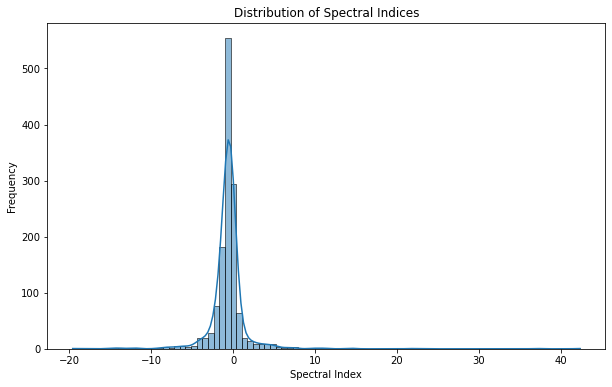

In [43]:
# Plot the distribution of spectral indices
plt.figure(figsize=(10, 6))
sns.histplot(spectral_indices['Spectral_Index'].dropna(), bins=90, kde=True)
plt.title('Distribution of Spectral Indices')
plt.xlabel('Spectral Index')
plt.ylabel('Frequency')
plt.show()

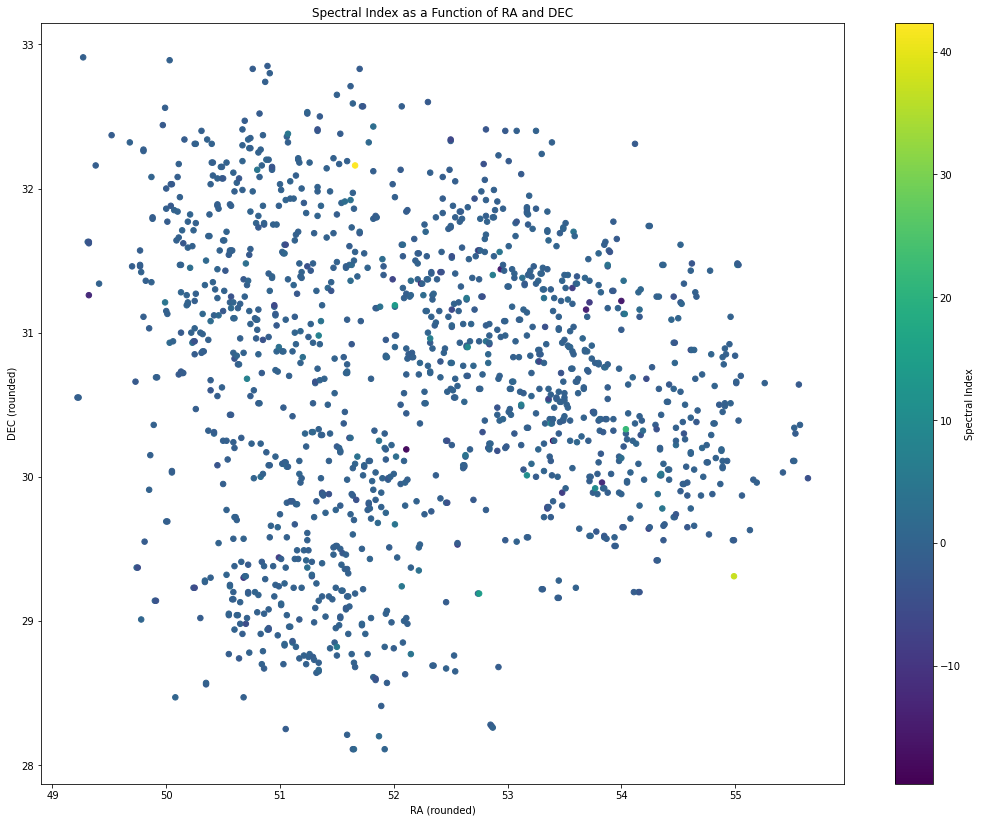

In [44]:
# Plot the spectral index as a function of RA and DEC
plt.figure(figsize=(18, 14))
plt.scatter(spectral_indices['RA_rounded'], spectral_indices['DEC_rounded'], c=spectral_indices['Spectral_Index'], cmap='viridis', s=30)
plt.colorbar(label='Spectral Index')
plt.xlabel('RA (rounded)')
plt.ylabel('DEC (rounded)')
plt.title('Spectral Index as a Function of RA and DEC')
plt.show()

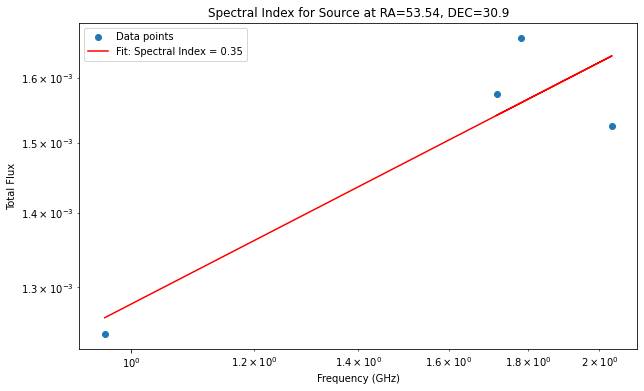

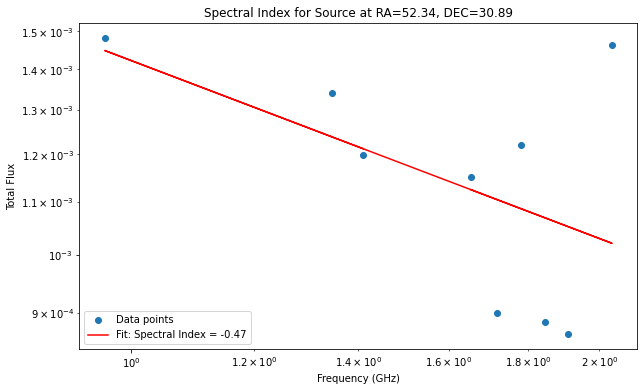

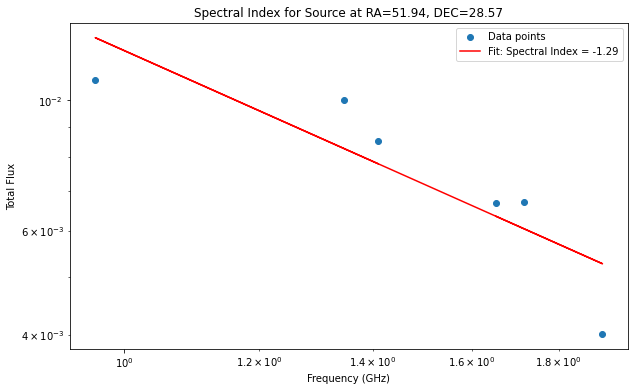

In [73]:
# Plot examples of spectral index calculations for selected sources
selected_sources = spectral_indices.sample(3)  # Randomly select 3 sources for example
for _, source in selected_sources.iterrows():
    ra = source['RA_rounded']
    dec = source['DEC_rounded']
    source_data = all_sources[(all_sources['RA_rounded'] == ra) & (all_sources['DEC_rounded'] == dec)]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(source_data['Frequency'], source_data['Total_flux'], label='Data points')
    plt.xscale('log')
    plt.yscale('log')
    
    # Fit a line to the log-log data
    log_freqs = np.log(source_data['Frequency'])
    log_fluxes = np.log(source_data['Total_flux'])
    slope, intercept = np.polyfit(log_freqs, log_fluxes, 1)
    fitted_fluxes = np.exp(intercept) * source_data['Frequency'] ** slope
    
    plt.plot(source_data['Frequency'], fitted_fluxes, label=f'Fit: Spectral Index = {slope:.2f}', color='red')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Total Flux')
    plt.title(f'Spectral Index for Source at RA={ra}, DEC={dec}')
    plt.legend()
    plt.show()

# Analysis

In [46]:
# Load and process dataframes
spw = [2, 3, 4, 5, 6, 8, 15, 16, 17]  # List of SPWs
dataframes = []

for i in spw:
    df = pd.read_csv(f'../paper1/csv/spw{i}.csv')
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    dataframes.append(df)

# Concatenate all dataframes
all_sources = pd.concat(dataframes)

# Group by unique sources
unique_sources = all_sources.groupby(['RA_rounded', 'DEC_rounded']).size().reset_index(name='counts')

# Count the number of unique sources
num_unique_sources = unique_sources.shape[0]

print(f"The total number of unique sources across all SPWs is: {num_unique_sources}")

The total number of unique sources across all SPWs is: 2009


## Common sources

In [47]:
# Load and process dataframes
spw = [2, 3, 4, 5, 6, 8, 15, 16, 17]  # List of SPWs
dataframes = []

for i in spw:
    df = pd.read_csv(f'../paper1/csv/spw{i}.csv')
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    df['SPW'] = i
    dataframes.append(df)

# Concatenate all dataframes
all_sources = pd.concat(dataframes)

# Group by unique sources and count the number of SPWs they appear in
source_counts = all_sources.groupby(['RA_rounded', 'DEC_rounded']).agg({
    'SPW': pd.Series.nunique
}).reset_index()
source_counts.rename(columns={'SPW': 'spw_count'}, inplace=True)

# Function to filter sources by the number of SPWs they appear in
def filter_sources_by_count(source_counts, count):
    return source_counts[source_counts['spw_count'] == count]

# Save sources by their appearance count in separate CSV files
for count in range(1, len(spw) + 1):
    filtered_sources = filter_sources_by_count(source_counts, count)
    if not filtered_sources.empty:
        filtered_sources.to_csv(f'../paper1/csv/sources_appearing_in_{count}_spws.csv', index=False)
        print(f"Sources appearing in exactly {count} SPWs saved to CSV file.")

print("Processing and saving sources by appearance counts completed.")

Sources appearing in exactly 1 SPWs saved to CSV file.
Sources appearing in exactly 2 SPWs saved to CSV file.
Sources appearing in exactly 3 SPWs saved to CSV file.
Sources appearing in exactly 4 SPWs saved to CSV file.
Sources appearing in exactly 5 SPWs saved to CSV file.
Sources appearing in exactly 6 SPWs saved to CSV file.
Sources appearing in exactly 7 SPWs saved to CSV file.
Sources appearing in exactly 8 SPWs saved to CSV file.
Sources appearing in exactly 9 SPWs saved to CSV file.
Processing and saving sources by appearance counts completed.


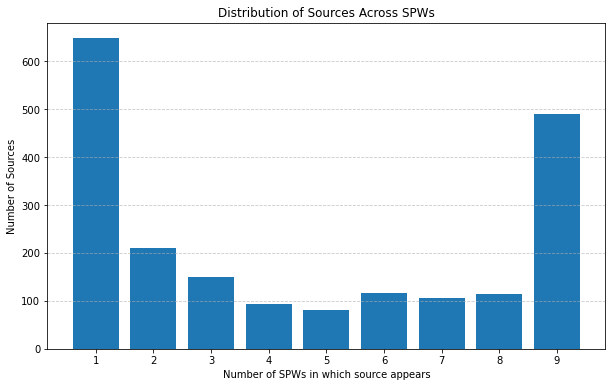

In [48]:
# Plot histogram of the distribution of sources across SPWs
plt.figure(figsize=(10, 6))
plt.hist(source_counts['spw_count'], bins=range(1, len(spw) + 2), align='left', rwidth=0.8)
plt.xlabel('Number of SPWs in which source appears')
plt.ylabel('Number of Sources')
plt.title('Distribution of Sources Across SPWs')
plt.xticks(range(1, len(spw) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Location of once appeared souces

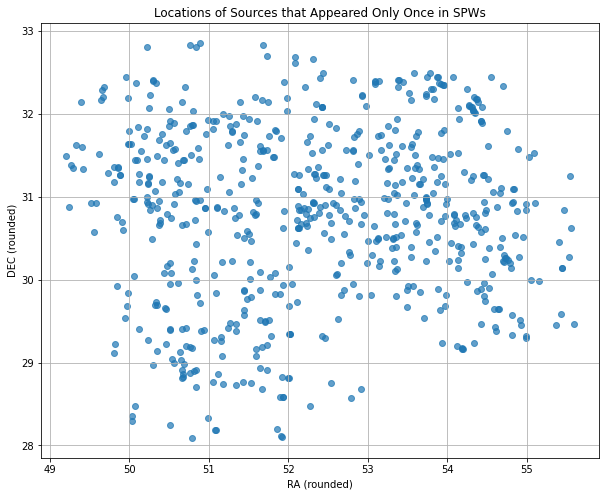

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and process dataframes
spw = [2, 3, 4, 5, 6, 8, 15, 16, 17]  # List of SPWs
dataframes = []

for i in spw:
    df = pd.read_csv(f'../paper1/csv/spw{i}.csv')
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    df['SPW'] = i
    dataframes.append(df)

# Concatenate all dataframes
all_sources = pd.concat(dataframes)

# Group by unique sources and count the number of SPWs they appear in
source_counts = all_sources.groupby(['RA_rounded', 'DEC_rounded']).agg({
    'SPW': pd.Series.nunique
}).reset_index()
source_counts.rename(columns={'SPW': 'spw_count'}, inplace=True)

# Filter sources that appear only once in the SPWs
sources_once = source_counts[source_counts['spw_count'] == 1]

# Plot the locations of sources that appeared only once
plt.figure(figsize=(10, 8))
plt.scatter(sources_once['RA_rounded'], sources_once['DEC_rounded'], alpha=0.7)
plt.title('Locations of Sources that Appeared Only Once in SPWs')
plt.xlabel('RA (rounded)')
plt.ylabel('DEC (rounded)')
plt.grid(True)
plt.show()


## Completeness

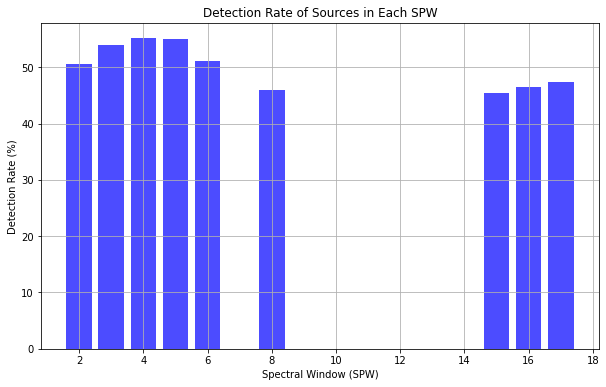

Completeness results:
2     50.572424
3     53.857641
4     55.151817
5     55.052265
6     51.070184
8     45.943255
15    45.495271
16    46.441015
17    47.386760
Name: SPW, dtype: float64


In [50]:
# Load and process dataframes
spw = [2, 3, 4, 5, 6, 8, 15, 16, 17]  # List of SPWs
dataframes = []

for i in spw:
    df = pd.read_csv(f'../paper1/csv/spw{i}.csv')
    df['RA_rounded'] = df['RA'].round(2)
    df['DEC_rounded'] = df['DEC'].round(2)
    df['SPW'] = i
    dataframes.append(df)

# Concatenate all dataframes
all_sources = pd.concat(dataframes)

# Group by unique sources and count the number of SPWs they appear in
source_counts = all_sources.groupby(['RA_rounded', 'DEC_rounded']).agg({
    'SPW': pd.Series.nunique
}).reset_index()
source_counts.rename(columns={'SPW': 'spw_count'}, inplace=True)

# Count the number of sources detected in each SPW
spw_counts = all_sources['SPW'].value_counts().sort_index()

# Calculate the detection rate for each SPW
total_unique_sources = len(source_counts)
detection_rate = spw_counts / total_unique_sources * 100

# Plot the detection rate
plt.figure(figsize=(10, 6))
plt.bar(spw_counts.index, detection_rate, alpha=0.7, color='b')
plt.xlabel('Spectral Window (SPW)')
plt.ylabel('Detection Rate (%)')
plt.title('Detection Rate of Sources in Each SPW')
plt.grid(True)
plt.show()

# Print completeness results
print("Completeness results:")
print(detection_rate)

# Save detection rates to CSV
detection_rate.to_csv('../paper1/csv/detection_rate_per_spw.csv', header=['Detection Rate'])


# Latex

In [66]:
updated_dataframes = []

for s in spw:
    df = pd.read_csv(f'../paper1/csv/spw{s}.csv')
    
    updated_dataframes.append(df)
    print(f"Shape of DataFrame for SPW {s} after reading from CSV: {df.shape}")

print("Reading process completed.")

Shape of DataFrame for SPW 2 after reading from CSV: (1016, 50)
Shape of DataFrame for SPW 3 after reading from CSV: (1082, 50)
Shape of DataFrame for SPW 4 after reading from CSV: (1108, 50)
Shape of DataFrame for SPW 5 after reading from CSV: (1106, 50)
Shape of DataFrame for SPW 6 after reading from CSV: (1026, 50)
Shape of DataFrame for SPW 8 after reading from CSV: (923, 50)
Shape of DataFrame for SPW 15 after reading from CSV: (914, 50)
Shape of DataFrame for SPW 16 after reading from CSV: (933, 50)
Shape of DataFrame for SPW 17 after reading from CSV: (952, 50)
Reading process completed.


In [67]:
# Columns of interest with errors
loc_columns = ['RA', 'E_RA', 'DEC', 'E_DEC', 'Spectral_Index']
flux_columns = ['Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'Isl_rms']

In [68]:
processed_dataframes = []

for df in updated_dataframes:
    # Select the columns of interest
    selected_columns = df[loc_columns + flux_columns].copy()
    
    # Multiply the relevant columns by 1e3 to convert to mJy
    selected_columns[flux_columns] = selected_columns[flux_columns] * 1e3
    
    # Round fluxes and spectral index to 2 decimal places and keep trailing zeros
    selected_columns[flux_columns] = selected_columns[flux_columns].applymap(lambda x: f"{x:.2f}")
    selected_columns['Spectral_Index'] = selected_columns['Spectral_Index'].map('{:.2f}'.format)
    
    # Round RA and DEC and their errors to 5 decimal places and keep trailing zeros
    selected_columns[['RA', 'E_RA', 'DEC', 'E_DEC']] = selected_columns[['RA', 'E_RA', 'DEC', 'E_DEC']].applymap(lambda x: f"{x:.5f}")
    
    # Append the processed dataframe to the list
    processed_dataframes.append(selected_columns)

# Print the processed dataframes for verification
for i, df in enumerate(processed_dataframes):
    print(f"Processed DataFrame for SPW {spw[i]}:")
    print(df.head())

# Optionally, save the processed dataframes to new CSV files
for i, df in enumerate(processed_dataframes):
    df.to_csv(f'../paper1/csv/processed_spw{spw[i]}.csv', index=False)

print("Processing and saving completed.")

Processed DataFrame for SPW 2:
         RA     E_RA       DEC    E_DEC Spectral_Index Total_flux  \
0  49.22463  0.00109  30.55155  0.00098          -1.60       1.02   
1  49.31474  0.00071  31.62559  0.00040          -0.10       2.74   
2  49.37870  0.00045  32.15640  0.00034          -1.45       3.44   
3  49.41496  0.00079  31.33934  0.00067          -0.41       1.81   
4  49.51611  0.00043  32.36928  0.00026          -1.51       4.73   

  E_Total_flux Peak_flux E_Peak_flux Isl_rms  
0         0.27      0.77        0.13    0.12  
1         0.43      2.22        0.21    0.21  
2         0.39      2.70        0.19    0.18  
3         0.48      1.80        0.27    0.27  
4         0.39      3.30        0.17    0.17  
Processed DataFrame for SPW 3:
         RA     E_RA       DEC    E_DEC Spectral_Index Total_flux  \
0  49.21222  0.00070  31.49077  0.00053            nan       0.65   
1  49.22743  0.00098  30.54946  0.00063          -0.82       0.95   
2  49.31600  0.00056  31.62517  0.

In [69]:
rename_dict = {
    'RA': r'\text{RA}',
    'E_RA': r'$\sigma_{\text{RA}}$',
    'DEC': r'\text{DEC}',
    'E_DEC': r'$\sigma_{\text{DEC}}$',
    'Total_flux': r'$S_{\text{total}}$',
    'E_Total_flux': r'$\sigma_{S_{\text{total}}}$',
    'Peak_flux': r'$S_{\text{peak}}$',
    'E_Peak_flux': r'$\sigma_{S_{\text{peak}}}$',
    'Isl_rms':r'$RMS$',
    'Spectral_Index':r'$\alpha$'
    
}

In [70]:
rows_per_chunk=60
for i, df in enumerate(processed_dataframes):
    # Rename the columns for LaTeX table
    df.rename(columns=rename_dict, inplace=True)
    
    num_chunks = (len(df) // rows_per_chunk) + 1
    
    for chunk_index in range(num_chunks):
        start_row = chunk_index * rows_per_chunk
        end_row = start_row + rows_per_chunk
        chunk_df = df.iloc[start_row:end_row]
        
        # Convert the dataframe chunk to a LaTeX table using to_latex from DataFrame
        latex_table = chunk_df.style.hide(axis='index').to_latex(hrules=True)
        
        # Save the LaTeX table to a .tex file
        with open(f'../paper1/csv/latex/spw{spw[i]}_part{chunk_index + 1}.tex', 'w') as file:
            file.write(latex_table)

print("Processing and saving to LaTeX longtables completed.")

Processing and saving to LaTeX longtables completed.


In [71]:
processed_dataframes[1]

,\text{RA},$\sigma_{\text{RA}}$,\text{DEC},$\sigma_{\text{DEC}}$,$\alpha$,$S_{\text{total}}$,$\sigma_{S_{\text{total}}}$,$S_{\text{peak}}$,$\sigma_{S_{\text{peak}}}$,$RMS$
0,49.21222,0.00070,31.49077,0.00053,nan,0.65,0.20,0.90,0.14,0.16
1,49.22743,0.00098,30.54946,0.00063,-0.82,0.95,0.24,0.76,0.12,0.11
2,49.31600,0.00056,31.62517,0.00039,-3.60,3.03,0.47,2.61,0.24,0.24
3,49.37797,0.00040,32.15667,0.00034,-1.45,3.56,0.33,2.37,0.14,0.14
4,49.41393,0.00118,31.33916,0.00060,-0.41,2.04,0.49,1.64,0.23,0.24
...,...,...,...,...,...,...,...,...,...,...
1077,55.51444,0.00090,30.11003,0.00058,-1.95,0.92,0.26,0.95,0.15,0.16
1078,55.52019,0.00023,30.34399,0.00017,-0.43,4.38,0.32,4.30,0.18,0.18
1079,55.52620,0.00185,30.30356,0.00108,-1.55,1.30,0.40,0.76,0.16,0.15
1080,55.56351,0.00071,30.63577,0.00050,-2.32,1.10,0.24,1.11,0.14,0.14


In [72]:
len(processed_dataframes)

9